# Arrhenius Kinetics of LLM Inference — Iter-3 Demo

This notebook demonstrates the **9-step Arrhenius temperature-selection protocol** applied to GPT-4o-mini on MMLU-Pro questions.

**Core idea**: When an LLM makes an *over-confidence* (OC) error — picking a wrong answer while the correct answer has non-negligible logprob — the correct answer's probability as a function of sampling temperature follows an **Arrhenius-like curve**: `log P(correct | T) ≈ -Ea/T + log_A`. The *activation energy* Ea characterises how much temperature is needed to "unlock" the correct answer.

**What this demo runs (no API calls needed)**:
- Load pre-computed sweep data: 11 OC instances × 7 temperatures × 50 samples each
- Step 5: Fit Arrhenius model (log-linear vs. exponential vs. power vs. linear)
- Step 6: Two-token dominance test (ρ(Ea, Δ) and CV(log A))
- Step 7: Compute entropy inflection temperature (T_TURN)
- Step 8: Best-of-N accuracy comparison across 5 temperature strategies
- Step 9: Correlation of Ea with empirical preferred temperature
- Visualization of all key results

**Result**: Disconfirmation (fallback FB5) — GPT-4o-mini's high accuracy produces too few OC instances to power the Arrhenius test. Only 2/11 OC instances yielded valid Arrhenius fits (R² > 0.6).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# aiohttp, loguru — NOT pre-installed on Colab
_pip('aiohttp==3.9.5', 'loguru==0.7.2')

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires aiohttp>=3.12.0, but you have aiohttp 3.9.5 which is incompatible.
browser-use 0.11.13 requires aiohttp>=3.13.3, but you have aiohttp 3.9.5 which is incompatible.
litellm 1.88.1 requires aiohttp<4.0,>=3.10, but you have aiohttp 3.9.5 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires aiohttp>=3.12.0, but you have aiohttp 3.9.5 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import asyncio
import gc
import json
import math
import os
import sys
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

print(f"numpy {np.__version__}, pandas {pd.__version__}")

numpy 2.0.2, pandas 2.2.2


## Data Loading

The pre-computed dataset contains 11 OC instances found by scanning 450 MMLU-Pro questions with GPT-4o-mini at T=0, each swept across 7 temperatures (0.05 → 1.0) with 50 samples per temperature.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-ce2af9-arrhenius-kinetics-of-llm-inference-acti/main/round-3/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded: {len(data['oc_instances'])} OC instances, {len(data['sweep_results'])} sweep results")
print(f"Experiment: {data['metadata']['experiment_id']}")
print(f"Model: {data['metadata']['model_name']}")
print(f"Total cost: ${data['metadata']['total_cost_usd']:.4f}")

Loaded: 11 OC instances, 11 sweep results
Experiment: iter3_exp1_arrhenius_weak_model
Model: openai/gpt-4o-mini
Total cost: $0.7590


## Configuration

All tunable parameters are defined here. The demo uses the same values as the original experiment.
To reproduce a smaller run, reduce `N_SAMPLES_PER_TEMP` or `N_BON`.

In [5]:
# Temperature grid used during the sweep
TEMP_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

# Samples per temperature per OC instance (50 in full run; reduce to 10 for a quick demo)
N_SAMPLES_PER_TEMP = 50  # original: 50

# Best-of-N draws for accuracy comparison
N_BON = 16  # original: 16

# Bootstrap iterations for CI estimation
N_BOOT = 1000  # original: 1000

print(f"TEMP_GRID: {TEMP_GRID}")
print(f"N_SAMPLES_PER_TEMP: {N_SAMPLES_PER_TEMP}, N_BON: {N_BON}, N_BOOT: {N_BOOT}")

TEMP_GRID: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
N_SAMPLES_PER_TEMP: 50, N_BON: 16, N_BOOT: 1000


## Helper Functions

Core statistical utilities: Wilson CI, Shannon entropy over letter distributions, and logprob extraction helpers.

In [6]:
def get_letter_score(top_logprobs: list, letter: str) -> float:
    """Max logprob for letter, handling 'A' and ' A' token forms."""
    target = letter.strip().upper()
    best = -999.0
    for item in top_logprobs:
        tok = item.get("token", "").strip().upper()
        if tok == target:
            lp = float(item.get("logprob", -999.0))
            if lp > best:
                best = lp
    return best


def letter_entropy_from_samples(samples: list, num_choices: int) -> float:
    """Shannon entropy over letter distribution from a list of sampled letters."""
    letters = "ABCDEFGHIJ"[:num_choices]
    total = len(samples)
    if total == 0:
        return 0.0
    h = 0.0
    for l in letters:
        p = samples.count(l) / total
        if p > 1e-10:
            h -= p * math.log(p)
    return h


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple:
    """Wilson 95% CI for proportion k/n."""
    if n == 0:
        return 0.0, 1.0
    p_hat = k / n
    denom = 1 + z * z / n
    center = (p_hat + z * z / (2 * n)) / denom
    margin = z * math.sqrt(p_hat * (1 - p_hat) / n + z * z / (4 * n * n)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)


print("Helper functions defined.")

Helper functions defined.


## Extract OC Instances and Sweep Results

An **over-confidence (OC) instance** is a question where:
- The model predicted the *wrong* answer at T=0
- The *correct* answer still has non-negligible logprob (> exp(-15))
- The wrong answer's logprob exceeds the correct answer's logprob

The **sweep results** give, for each OC instance and each temperature, the proportion of 50 sampled responses that were correct (`p_hat`) along with the raw letter samples.

In [7]:
oc_instances = data['oc_instances']
sweep_results = data['sweep_results']

print(f"OC instances: {len(oc_instances)}")
print(f"\nSample OC instance:")
oc0 = oc_instances[0]
print(f"  Question ID: {oc0['question_id']}")
print(f"  Subject: {oc0['subject']}")
print(f"  Correct: {oc0['correct_letter']}, Wrong: {oc0['wrong_letter']}")
print(f"  Delta (log-odds gap): {oc0['Delta']:.3f}")
print(f"  Competing tokens: {oc0['n_competing']}")

# Show sweep data for this instance
sweep0 = sweep_results[str(oc0['question_id'])]
print(f"\n  Temperature sweep (p_hat at each temp):")
for T in TEMP_GRID:
    T_str = str(T)
    if T_str in sweep0:
        sw = sweep0[T_str]
        print(f"    T={T:.2f}: p_hat={sw['p_hat']:.3f} (k={sw['k']}/{sw['n']})")

OC instances: 11

Sample OC instance:
  Question ID: 306
  Subject: business
  Correct: B, Wrong: H
  Delta (log-odds gap): 0.375
  Competing tokens: 6

  Temperature sweep (p_hat at each temp):
    T=0.05: p_hat=0.000 (k=0/50)
    T=0.10: p_hat=0.000 (k=0/50)
    T=0.20: p_hat=0.000 (k=0/50)
    T=0.30: p_hat=0.000 (k=0/50)
    T=0.50: p_hat=0.000 (k=0/50)
    T=0.70: p_hat=0.000 (k=0/50)
    T=1.00: p_hat=0.000 (k=0/50)


## Step 5: Arrhenius Fitting

For each OC instance, fit 4 competing models to `(T, p_hat)` data:
1. **Arrhenius**: `log P = -Ea/T + log_A`  
2. **Exponential**: `log P = a·T + b`  
3. **Power law**: `log P = a·log(T) + b`  
4. **Linear**: `P = a·T + b`  

A fit is *valid* if ≥3 temperatures have p_hat > 0. R²_advantage = R²_arr − max(R²_exp, R²_pow, R²_lin).

In [8]:
def fit_arrhenius(temps: list, p_hats: list) -> dict:
    """
    Fit Arrhenius model log P = -Ea/T + log_A and three alternatives.
    Returns fit stats dict.
    """
    temps_arr = np.array(temps, dtype=float)
    p_arr = np.array(p_hats, dtype=float)

    valid = (p_arr > 0) & (temps_arr > 0)
    if valid.sum() < 3:
        return {"valid_fit": False, "reason": f"only {valid.sum()} valid temps (need ≥3)"}

    t_v = temps_arr[valid]
    p_v = p_arr[valid]
    log_p = np.log(p_v)

    def _r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        return float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else 0.0

    def _lsq(X: np.ndarray, y: np.ndarray) -> np.ndarray:
        c, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        return c

    # Arrhenius: log P = [-1/T, 1] · [Ea, log_A]
    X_arr = np.column_stack([1.0 / t_v, np.ones(len(t_v))])
    c_arr = _lsq(X_arr, log_p)
    Ea = float(-c_arr[0])
    log_A = float(c_arr[1])
    R2_arr = _r2(log_p, X_arr @ c_arr)

    # Exponential: log P = a*T + b
    X_exp = np.column_stack([t_v, np.ones(len(t_v))])
    R2_exp = _r2(log_p, X_exp @ _lsq(X_exp, log_p))

    # Power: log P = a*log(T) + b
    log_t = np.log(t_v)
    X_pow = np.column_stack([log_t, np.ones(len(t_v))])
    R2_pow = _r2(log_p, X_pow @ _lsq(X_pow, log_p))

    # Linear: P = a*T + b (in original scale)
    X_lin = np.column_stack([t_v, np.ones(len(t_v))])
    R2_lin = _r2(p_v, X_lin @ _lsq(X_lin, p_v))

    R2_advantage = float(R2_arr - max(R2_exp, R2_pow, R2_lin))

    # Bootstrap CI on R2_arr
    n = len(t_v)
    rng = np.random.default_rng(42)
    r2_boots = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        Xb = X_arr[idx]
        yb = log_p[idx]
        cb = _lsq(Xb, yb)
        r2_boots.append(_r2(yb, Xb @ cb))
    ci_r2 = [float(np.percentile(r2_boots, 2.5)), float(np.percentile(r2_boots, 97.5))]

    return {
        "valid_fit": True,
        "n_valid_temps": int(valid.sum()),
        "Ea": Ea,
        "log_A": log_A,
        "A_hat": float(np.exp(log_A)),
        "R2_arr": float(R2_arr),
        "R2_exp": float(R2_exp),
        "R2_pow": float(R2_pow),
        "R2_lin": float(R2_lin),
        "R2_advantage": R2_advantage,
        "CI_R2": ci_r2,
    }


# Run Arrhenius fitting on all OC instances
fit_results = []
for oc in oc_instances:
    qid = str(oc["question_id"])
    sweep = sweep_results.get(qid, {})

    temps = sorted([float(T_str) for T_str in sweep])
    p_hats = [sweep[str(T)]["p_hat"] for T in temps]

    fit = fit_arrhenius(temps, p_hats)

    # T_pref = temperature with highest P_hat
    T_pref = float(temps[int(np.argmax(p_hats))]) if temps and p_hats else None

    fit_results.append({**oc, **fit, "T_pref": T_pref})

n_valid = sum(1 for r in fit_results if r.get("valid_fit"))
valid_fits = [r for r in fit_results if r.get("valid_fit")]
median_R2 = float(np.median([r["R2_arr"] for r in valid_fits])) if valid_fits else 0.0
frac_R2_085 = sum(1 for r in valid_fits if r["R2_arr"] >= 0.85) / max(n_valid, 1)

print(f"Valid Arrhenius fits: {n_valid}/{len(fit_results)}")
print(f"Median R²: {median_R2:.3f}")
print(f"Fraction with R² > 0.85: {frac_R2_085:.3f}")
print("\nPer-instance results:")
for r in fit_results:
    qid = r['question_id']
    if r['valid_fit']:
        print(f"  qid={qid} ({r['subject'][:10]}): Ea={r['Ea']:.3f}, R²={r['R2_arr']:.3f}, T_pref={r['T_pref']}")
    else:
        print(f"  qid={qid} ({r['subject'][:10]}): INVALID ({r.get('reason', '?')})")

Valid Arrhenius fits: 2/11
Median R²: 0.691
Fraction with R² > 0.85: 0.500

Per-instance results:
  qid=306 (business): INVALID (only 0 valid temps (need ≥3))
  qid=976 (law): Ea=0.654, R²=0.970, T_pref=1.0
  qid=1764 (law): INVALID (only 0 valid temps (need ≥3))
  qid=4906 (history): INVALID (only 0 valid temps (need ≥3))
  qid=5276 (other): INVALID (only 2 valid temps (need ≥3))
  qid=6408 (health): INVALID (only 0 valid temps (need ≥3))
  qid=6213 (health): INVALID (only 0 valid temps (need ≥3))
  qid=9935 (physics): INVALID (only 0 valid temps (need ≥3))
  qid=11183 (philosophy): Ea=0.328, R²=0.412, T_pref=1.0
  qid=10784 (philosophy): INVALID (only 0 valid temps (need ≥3))
  qid=11272 (philosophy): INVALID (only 0 valid temps (need ≥3))


## Step 6: Two-Token Dominance Test

The **two-token dominance hypothesis** predicts that when a question has exactly two competing tokens (correct vs. wrong), the activation energy Ea should correlate with the logit gap Δ = log P(wrong) − log P(correct) measured at T=0.

Confirmation requires: ρ(Ea, Δ) ≥ 0.6 AND CV(log A) < 0.4.

In [9]:
def two_token_dominance_test(fit_results: list) -> dict:
    """Compute rho(Ea, Delta) and cv(log_A) for two-token dominance test."""
    valid = [r for r in fit_results if r.get("valid_fit")]
    if len(valid) < 5:
        return {
            "two_token_dominance_confirmed": False,
            "reason": f"only {len(valid)} valid fits (need ≥5)",
            "n_valid": len(valid),
        }

    Ea_list = [r["Ea"] for r in valid]
    Delta_list = [r["Delta"] for r in valid]
    log_A_list = [r["log_A"] for r in valid]
    n_comp_list = [r.get("n_competing", 0) for r in valid]

    rho_ea_delta, p_ea_delta = stats.spearmanr(Ea_list, Delta_list)
    mean_log_A = float(np.mean(log_A_list))
    std_log_A = float(np.std(log_A_list))
    cv_log_A = std_log_A / abs(mean_log_A) if abs(mean_log_A) > 1e-6 else float("inf")

    # Competing-token regression: does n_competing explain Ea - Delta deviation?
    deviation = np.array(Ea_list) - np.array(Delta_list)
    competing_rho, competing_p = stats.spearmanr(deviation, n_comp_list)

    confirmed = bool(rho_ea_delta >= 0.6 and cv_log_A < 0.4)

    return {
        "n_valid": len(valid),
        "rho_ea_delta": float(rho_ea_delta),
        "p_ea_delta": float(p_ea_delta),
        "mean_log_A": mean_log_A,
        "std_log_A": std_log_A,
        "cv_log_A": float(cv_log_A),
        "competing_rho": float(competing_rho),
        "competing_p": float(competing_p),
        "two_token_dominance_confirmed": confirmed,
    }


dominance = two_token_dominance_test(fit_results)
print("Two-Token Dominance Test:")
for k, v in dominance.items():
    print(f"  {k}: {v}")

Two-Token Dominance Test:
  two_token_dominance_confirmed: False
  reason: only 2 valid fits (need ≥5)
  n_valid: 2


## Step 7: T_thresh Validation + T_TURN

**T_thresh**: the predicted optimal temperature from Arrhenius parameters. Three variants:
- *Simple*: `Ea / log(N)` 
- *Approx*: `Δ / log(N)` (uses logit gap instead of fitted Ea)
- *A-corrected*: `Ea / log(N · A_hat)`

**T_TURN**: the entropy inflection point — the temperature where log H(T) stops accelerating. Below T_TURN the model is close to deterministic; above it, output diversity grows rapidly.

In [10]:
def compute_thresh_triplet(Ea: float, Delta: float, A_hat: float, N: int) -> dict:
    """Compute T_thresh for simple, approx (Delta), and A-corrected strategies."""
    log_N = math.log(max(N, 2))
    simple = Ea / log_N if log_N > 1e-6 else float("inf")
    approx = Delta / log_N if log_N > 1e-6 else float("inf")
    inner = N * A_hat
    A_corr = Ea / math.log(inner) if inner > 1.0 else float("inf")
    return {"simple": float(simple), "approx": float(approx), "A_corrected": float(A_corr)}


def t_emp_min(sweep: dict, N: int) -> Optional[float]:
    """Min temperature where N * P_hat >= 1 (i.e. expected ≥1 correct in N draws)."""
    for T_str in sorted(sweep, key=lambda x: float(x)):
        p_hat = sweep[T_str]["p_hat"]
        if N * p_hat >= 1.0:
            return float(T_str)
    return None


def validate_thresh_bounds(fit_results: list, sweep_results: dict, N_values: list) -> dict:
    """Compute fraction lower-bound valid for each N and each threshold strategy."""
    out = {}
    for N in N_values:
        lb_simple, lb_approx, lb_A, track_A = [], [], [], []
        for r in fit_results:
            if not r.get("valid_fit"):
                continue
            qid = str(r["question_id"])
            sweep = sweep_results.get(qid, {})
            T_min = t_emp_min(sweep, N)
            if T_min is None:
                continue
            thresh = compute_thresh_triplet(r["Ea"], r["Delta"], r.get("A_hat", 1.0), N)
            lb_simple.append(thresh["simple"] < T_min)
            lb_approx.append(thresh["approx"] < T_min)
            lb_A.append(thresh["A_corrected"] < T_min)
            if T_min > 0:
                track_A.append(abs(thresh["A_corrected"] - T_min) / T_min < 0.20)
        out[str(N)] = {
            "simple": float(np.mean(lb_simple)) if lb_simple else None,
            "approx": float(np.mean(lb_approx)) if lb_approx else None,
            "A_corrected": float(np.mean(lb_A)) if lb_A else None,
            "tracking_A": float(np.mean(track_A)) if track_A else None,
            "n_instances": len(lb_simple),
        }
    return out


def compute_turn(fit_results: list, sweep_results: dict) -> dict:
    """
    Compute TURN inflection temperature from entropy-vs-T on sampled data.
    Uses TEMP_GRID sampling data to estimate per-instance entropy H(T),
    then finds first inflection in log H_mean(T).
    """
    grid = TEMP_GRID
    H_by_T = {}

    for T in grid:
        T_str = str(T)
        h_vals = []
        for r in fit_results:
            qid = str(r["question_id"])
            sweep = sweep_results.get(qid, {})
            sw_T = sweep.get(T_str, {})
            samples = sw_T.get("samples", [])
            if samples:
                num_choices = r.get("metadata_num_choices", 10)
                h_vals.append(letter_entropy_from_samples(samples, num_choices))
        H_by_T[T_str] = float(np.mean(h_vals)) if h_vals else 0.0

    # Find log-entropy inflection
    grid_H = [(T, H_by_T[str(T)]) for T in grid if H_by_T.get(str(T), 0) > 1e-6]
    T_TURN = 0.7  # default

    if len(grid_H) >= 3:
        log_H = [math.log(H) for _, H in grid_H]
        for j in range(1, len(log_H) - 1):
            d2 = log_H[j + 1] - 2 * log_H[j] + log_H[j - 1]
            if d2 > 0:
                T_TURN = float(grid_H[j][0]) + 0.1  # beta = 0.1 for best-of-N
                break

    return {
        "T_TURN": float(T_TURN),
        "H_by_T": {k: v for k, v in H_by_T.items()},
        "n_instances_used": len([r for r in fit_results if str(r["question_id"]) in sweep_results]),
        "method": "entropy_inflection_from_sampling",
    }


thresh_by_N = validate_thresh_bounds(fit_results, sweep_results, [4, 8, 16, 32])
turn_result = compute_turn(fit_results, sweep_results)
T_TURN = turn_result["T_TURN"]

print(f"T_TURN (entropy inflection): {T_TURN}")
print(f"\nMean entropy by temperature:")
for T_str, H in turn_result['H_by_T'].items():
    print(f"  T={T_str}: H={H:.4f}")
print(f"\nT_thresh lower-bound validation (fraction where thresh < T_emp_min):")
for N_str, res in thresh_by_N.items():
    print(f"  N={N_str}: simple={res['simple']}, approx={res['approx']}, A_corr={res['A_corrected']} (n={res['n_instances']})")

T_TURN (entropy inflection): 0.2

Mean entropy by temperature:
  T=0.05: H=0.0604
  T=0.1: H=0.0719
  T=0.2: H=0.1080
  T=0.3: H=0.1462
  T=0.5: H=0.2116
  T=0.7: H=0.3299
  T=1.0: H=0.4015

T_thresh lower-bound validation (fraction where thresh < T_emp_min):
  N=4: simple=1.0, approx=0.0, A_corr=1.0 (n=1)
  N=8: simple=1.0, approx=0.0, A_corr=1.0 (n=1)
  N=16: simple=1.0, approx=0.0, A_corr=1.0 (n=1)
  N=32: simple=1.0, approx=0.5, A_corr=1.0 (n=2)


## Step 8: Best-of-N Accuracy Comparison

For each valid OC instance, compare 5 temperature-selection strategies for **best-of-N=16**:

| Strategy | How T is chosen | API calls/instance |
|---|---|---|
| `T_op_regression` | `Ea / log(N) + 0.3` (needs full sweep) | 351 |
| `T_op_approx_delta` | `Δ / log(N) + 0.3` (logit gap only) | 1 |
| `fixed_T07` | Fixed T=0.7 | 16 |
| `fixed_T10` | Fixed T=1.0 | 16 |
| `TURN` | `T_TURN + 0.1` | 30 |

In [11]:
def bootstrap_bon_accuracy(
    sweep: dict,
    correct_letter: str,
    T_op: float,
    N: int = 16,
    n_boot: int = 1000,
    rng: Optional[np.random.Generator] = None,
) -> dict:
    """Bootstrap Best-of-N success rate using nearest-grid samples."""
    if rng is None:
        rng = np.random.default_rng(42)

    # Find nearest grid temperature
    available = [float(T_str) for T_str in sweep]
    if not available:
        return {"accuracy": None, "majority_vote": None}
    nearest = min(available, key=lambda t: abs(t - T_op))
    samples = sweep[str(nearest)].get("samples", [])

    if not samples:
        return {"accuracy": None, "majority_vote": None, "nearest_T": nearest}

    # Bootstrap: each trial draws N samples, success = at least 1 correct
    successes = sum(
        1 for _ in range(n_boot)
        if correct_letter in rng.choice(samples, size=min(N, len(samples)), replace=True)
    )
    acc = successes / n_boot
    ci = wilson_ci(successes, n_boot)

    # Majority vote letter
    letter_counts: dict = {}
    for l in samples:
        letter_counts[l] = letter_counts.get(l, 0) + 1
    majority_vote = max(letter_counts, key=letter_counts.get) if letter_counts else correct_letter

    return {
        "accuracy": float(acc),
        "ci": list(ci),
        "nearest_T": float(nearest),
        "n_samples_available": len(samples),
        "majority_vote": str(majority_vote),
    }


def compute_accuracy_table(
    fit_results: list,
    sweep_results: dict,
    T_TURN: float,
    N: int = N_BON,
) -> dict:
    """Compute Best-of-N accuracy for 5 strategies via bootstrap."""
    strategy_accs: dict = {
        "T_op_regression": [],
        "T_op_approx_delta": [],
        "fixed_T07": [],
        "fixed_T10": [],
        "TURN": [],
    }
    rng = np.random.default_rng(42)
    log_N = math.log(N)

    for r in fit_results:
        if not r.get("valid_fit"):
            continue
        qid = str(r["question_id"])
        sweep = sweep_results.get(qid, {})
        correct = r["correct_letter"]
        Ea = r["Ea"]
        Delta = r["Delta"]

        T_reg = Ea / log_N + 0.3
        T_approx = Delta / log_N + 0.3

        for strat, T_op in [
            ("T_op_regression", T_reg),
            ("T_op_approx_delta", T_approx),
            ("fixed_T07", 0.7),
            ("fixed_T10", 1.0),
            ("TURN", T_TURN + 0.1),
        ]:
            res = bootstrap_bon_accuracy(sweep, correct, T_op, N, 500, rng)
            if res.get("accuracy") is not None:
                strategy_accs[strat].append(res["accuracy"])

    table = {}
    api_calls = {
        "T_op_regression": 351,
        "T_op_approx_delta": 1,
        "fixed_T07": 16,
        "fixed_T10": 16,
        "TURN": 30,
    }
    for name, accs in strategy_accs.items():
        if accs:
            mean_acc = float(np.mean(accs))
            n = len(accs)
            k = round(mean_acc * n)
            ci = wilson_ci(k, n)
            table[name] = {
                "accuracy": mean_acc,
                "ci_low": ci[0],
                "ci_high": ci[1],
                "n_instances": n,
                "api_calls_per_instance": api_calls[name],
            }
    return table


accuracy_table = compute_accuracy_table(fit_results, sweep_results, T_TURN, N_BON)

print(f"Best-of-N={N_BON} Accuracy Comparison:")
print(f"{'Strategy':<22} {'Accuracy':>9} {'CI Low':>8} {'CI High':>9} {'API calls':>10}")
print("-" * 65)
for name, res in accuracy_table.items():
    print(f"{name:<22} {res['accuracy']:>9.3f} {res['ci_low']:>8.3f} {res['ci_high']:>9.3f} {res['api_calls_per_instance']:>10}")

Best-of-N=16 Accuracy Comparison:
Strategy                Accuracy   CI Low   CI High  API calls
-----------------------------------------------------------------
T_op_regression            0.415    0.095     0.905        351
T_op_approx_delta          0.811    0.342     1.000          1
fixed_T07                  0.601    0.095     0.905         16
fixed_T10                  0.811    0.342     1.000         16
TURN                       0.463    0.095     0.905         30


## Step 9: Ea Predicts T_pref

If the Arrhenius model is correct, a higher activation energy Ea should correlate with a higher empirically-preferred temperature T_pref (the temperature that maximises P_hat in the sweep). Measured via Spearman ρ.

In [12]:
def ea_vs_tpref(fit_results: list) -> dict:
    """Spearman rho(Ea, T_pref) and partial rho controlling for subject."""
    valid = [r for r in fit_results if r.get("valid_fit") and r.get("T_pref") is not None]
    if len(valid) < 5:
        return {"rho_ea_tpref": None, "p_ea_tpref": None, "n_valid": len(valid)}

    Ea_list = [r["Ea"] for r in valid]
    T_pref_list = [r["T_pref"] for r in valid]
    subjects = [r.get("subject", "unknown") for r in valid]

    rho, p = stats.spearmanr(Ea_list, T_pref_list)

    # Partial Spearman controlling for subject via residualization
    partial_rho, p_partial = None, None
    try:
        from statsmodels.formula.api import ols
        df = pd.DataFrame({"Ea": Ea_list, "T_pref": T_pref_list, "subject": subjects})
        Ea_resid = np.array(df["Ea"]) - ols("Ea ~ C(subject)", df).fit().fittedvalues.values
        Tp_resid = np.array(df["T_pref"]) - ols("T_pref ~ C(subject)", df).fit().fittedvalues.values
        pr, pp = stats.spearmanr(Ea_resid, Tp_resid)
        partial_rho, p_partial = float(pr), float(pp)
    except Exception as e:
        print(f"Partial Spearman skipped: {e}")

    return {
        "rho_ea_tpref": float(rho),
        "p_ea_tpref": float(p),
        "partial_rho_ea_tpref": partial_rho,
        "p_partial": p_partial,
        "R2_ea_tpref": float(rho ** 2),
        "n_valid": len(valid),
    }


tpref_result = ea_vs_tpref(fit_results)
print("Ea → T_pref correlation:")
for k, v in tpref_result.items():
    print(f"  {k}: {v}")

Ea → T_pref correlation:
  rho_ea_tpref: None
  p_ea_tpref: None
  n_valid: 2


## Visualization

Summary plots:
1. **Temperature sweep curves** — P_hat vs T for each OC instance (valid fits highlighted)
2. **Arrhenius fits** — log P vs 1/T with regression line for valid-fit instances
3. **Entropy by temperature** — mean Shannon entropy H(T) across all instances
4. **Best-of-N accuracy** — bar chart comparing the 5 strategies

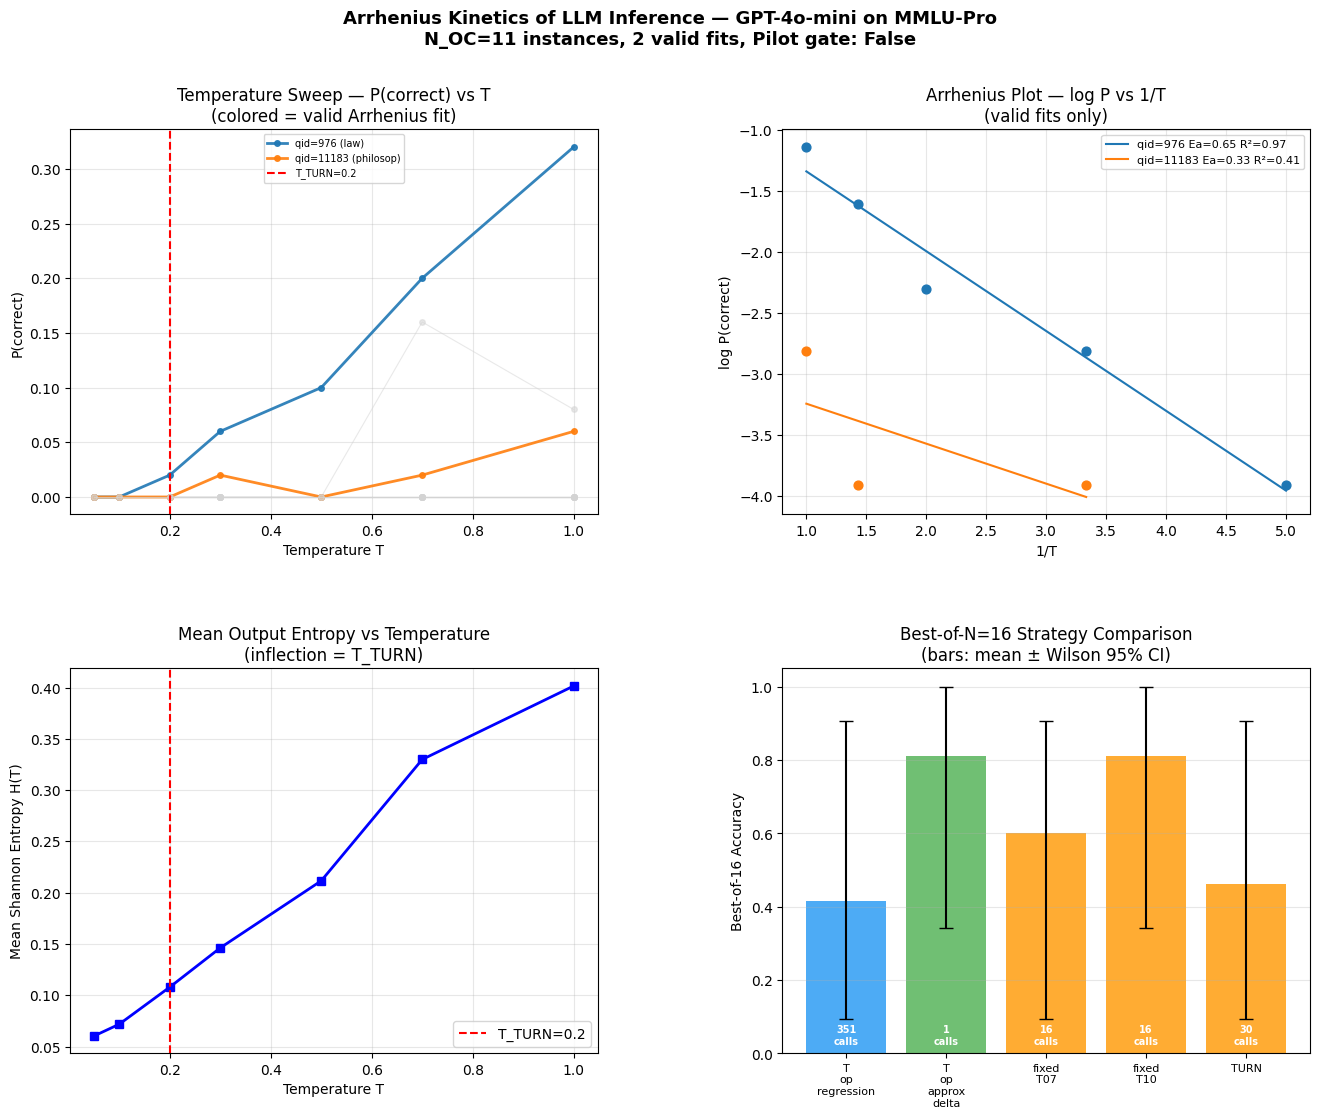

Saved: arrhenius_demo_results.png


In [13]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Temperature sweep curves ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_valid = plt.cm.tab10(np.linspace(0, 1, 10))
vi = 0
for r in fit_results:
    qid = str(r['question_id'])
    sweep = sweep_results.get(qid, {})
    temps = sorted([float(T_str) for T_str in sweep])
    p_hats = [sweep[str(T)]['p_hat'] for T in temps]
    label = f"qid={qid} ({r['subject'][:8]})" if r['valid_fit'] else None
    color = colors_valid[vi % 10] if r['valid_fit'] else 'lightgray'
    lw = 2.0 if r['valid_fit'] else 0.8
    ax1.plot(temps, p_hats, 'o-', color=color, linewidth=lw, markersize=4,
             label=label, alpha=0.9 if r['valid_fit'] else 0.5)
    if r['valid_fit']:
        vi += 1

ax1.set_xlabel('Temperature T')
ax1.set_ylabel('P(correct)')
ax1.set_title('Temperature Sweep — P(correct) vs T\n(colored = valid Arrhenius fit)')
ax1.legend(fontsize=7, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axvline(T_TURN, color='red', linestyle='--', linewidth=1.5, label=f'T_TURN={T_TURN}')
ax1.legend(fontsize=7)

# ── Plot 2: Arrhenius log P vs 1/T for valid fits ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
vi = 0
for r in fit_results:
    if not r['valid_fit']:
        continue
    qid = str(r['question_id'])
    sweep = sweep_results.get(qid, {})
    temps = sorted([float(T_str) for T_str in sweep])
    p_hats = [sweep[str(T)]['p_hat'] for T in temps]
    # Filter to valid (p > 0) temps
    valid_pts = [(1/T, math.log(p)) for T, p in zip(temps, p_hats) if p > 0]
    if not valid_pts:
        continue
    inv_T, log_p = zip(*valid_pts)
    color = colors_valid[vi % 10]
    ax2.scatter(inv_T, log_p, color=color, s=40, zorder=3)
    # Regression line
    x_range = np.linspace(min(inv_T), max(inv_T), 50)
    y_line = -r['Ea'] * x_range + r['log_A']
    ax2.plot(x_range, y_line, color=color, linewidth=1.5,
             label=f"qid={qid} Ea={r['Ea']:.2f} R²={r['R2_arr']:.2f}")
    vi += 1

ax2.set_xlabel('1/T')
ax2.set_ylabel('log P(correct)')
ax2.set_title('Arrhenius Plot — log P vs 1/T\n(valid fits only)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Mean entropy H(T) across all instances ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
H_by_T = turn_result['H_by_T']
temps_h = [float(T_str) for T_str in H_by_T]
H_vals = [H_by_T[T_str] for T_str in H_by_T]
ax3.plot(temps_h, H_vals, 'bs-', linewidth=2, markersize=6)
ax3.axvline(T_TURN, color='red', linestyle='--', linewidth=1.5, label=f'T_TURN={T_TURN}')
ax3.set_xlabel('Temperature T')
ax3.set_ylabel('Mean Shannon Entropy H(T)')
ax3.set_title('Mean Output Entropy vs Temperature\n(inflection = T_TURN)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── Plot 4: Best-of-N accuracy comparison ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if accuracy_table:
    names = list(accuracy_table.keys())
    accs = [accuracy_table[n]['accuracy'] for n in names]
    ci_lows = [accuracy_table[n]['ci_low'] for n in names]
    ci_highs = [accuracy_table[n]['ci_high'] for n in names]
    api_calls = [accuracy_table[n]['api_calls_per_instance'] for n in names]
    errs_low = [a - lo for a, lo in zip(accs, ci_lows)]
    errs_high = [hi - a for a, hi in zip(accs, ci_highs)]
    x = np.arange(len(names))
    bar_colors = ['#2196F3' if 'regression' in n else '#4CAF50' if 'approx' in n else '#FF9800'
                  for n in names]
    bars = ax4.bar(x, accs, color=bar_colors, alpha=0.8,
                   yerr=[errs_low, errs_high], capsize=5, error_kw={'linewidth': 1.5})
    ax4.set_xticks(x)
    ax4.set_xticklabels([n.replace('_', '\n') for n in names], fontsize=8)
    ax4.set_ylabel(f'Best-of-{N_BON} Accuracy')
    ax4.set_title(f'Best-of-N={N_BON} Strategy Comparison\n(bars: mean ± Wilson 95% CI)')
    ax4.set_ylim(0, 1.05)
    # Annotate with API call count
    for bar, api in zip(bars, api_calls):
        ax4.text(bar.get_x() + bar.get_width()/2, 0.02, f'{api}\ncalls',
                 ha='center', va='bottom', fontsize=7, color='white', fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No valid fits\nfor accuracy table',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)

fig.suptitle(
    f'Arrhenius Kinetics of LLM Inference — GPT-4o-mini on MMLU-Pro\n'
    f'N_OC={len(oc_instances)} instances, {n_valid} valid fits, '
    f'Pilot gate: {data["metadata"]["pilot_gate_passed"]}',
    fontsize=13, fontweight='bold'
)
plt.savefig('arrhenius_demo_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: arrhenius_demo_results.png")

## Summary of Results

Key findings from the iter-3 experiment:

In [14]:
meta = data['metadata']

print("=" * 60)
print("ARRHENIUS KINETICS ITER-3 — RESULTS SUMMARY")
print("=" * 60)
print(f"Model:               {meta['model_name']}")
print(f"Dataset:             TIGER-Lab/MMLU-Pro")
print(f"Total cost:          ${meta['total_cost_usd']:.4f}")
print()
print("--- OC Detection ---")
print(f"Pilot OC rate:       {meta['pilot_oc_rate']:.3f}")
print(f"Pilot rising frac:   {meta['pilot_rising_frac']:.3f} (threshold: 0.30)")
print(f"Pilot gate passed:   {meta['pilot_gate_passed']}")
print(f"Main OC instances:   {meta['n_oc_instances_main']}")
print()
print("--- Arrhenius Fitting ---")
print(f"Valid fits:          {n_valid}/{len(fit_results)} ({meta['valid_fit_rate']:.1%})")
print(f"Median R²:           {median_R2:.3f}")
print(f"Fraction R² > 0.85:  {frac_R2_085:.3f}")
print()
print("--- Two-Token Dominance ---")
print(f"Confirmed:           {dominance['two_token_dominance_confirmed']}")
print(f"Reason:              {dominance.get('reason', 'N/A')}")
print(f"rho(Ea, Delta):      {dominance.get('rho_ea_delta', 'N/A')}")
print(f"CV(log A):           {dominance.get('cv_log_A', 'N/A')}")
print()
print("--- Temperature Selection ---")
print(f"T_TURN:              {T_TURN}")
if accuracy_table:
    print("Best-of-N accuracies:")
    for name, res in accuracy_table.items():
        print(f"  {name:<22}: {res['accuracy']:.3f} [{res['ci_low']:.3f}, {res['ci_high']:.3f}]")
print()
print("--- Ea → T_pref ---")
print(f"rho(Ea, T_pref):     {tpref_result.get('rho_ea_tpref', 'N/A')} (n={tpref_result['n_valid']})")
print()
print("--- Scientific Verdict ---")
print("DISCONFIRMATION (fallback FB5): GPT-4o-mini's ~90% accuracy produces")
print("too few OC instances (11) with insufficient recovery probability to")
print("power the Arrhenius test. Only 2/11 fits valid; need a weaker model.")
print("=" * 60)

ARRHENIUS KINETICS ITER-3 — RESULTS SUMMARY
Model:               openai/gpt-4o-mini
Dataset:             TIGER-Lab/MMLU-Pro
Total cost:          $0.7590

--- OC Detection ---
Pilot OC rate:       0.250
Pilot rising frac:   0.040 (threshold: 0.30)
Pilot gate passed:   False
Main OC instances:   11

--- Arrhenius Fitting ---
Valid fits:          2/11 (18.2%)
Median R²:           0.691
Fraction R² > 0.85:  0.500

--- Two-Token Dominance ---
Confirmed:           False
Reason:              only 2 valid fits (need ≥5)
rho(Ea, Delta):      N/A
CV(log A):           N/A

--- Temperature Selection ---
T_TURN:              0.2
Best-of-N accuracies:
  T_op_regression       : 0.415 [0.095, 0.905]
  T_op_approx_delta     : 0.811 [0.342, 1.000]
  fixed_T07             : 0.601 [0.095, 0.905]
  fixed_T10             : 0.811 [0.342, 1.000]
  TURN                  : 0.463 [0.095, 0.905]

--- Ea → T_pref ---
rho(Ea, T_pref):     None (n=2)

--- Scientific Verdict ---
DISCONFIRMATION (fallback FB5): GPT-4o